# RQ3 Sensitivity Analysis

This notebook tests the robustness of RQ3 predictive findings against two modeling choices:

1. **Processing cost base ($12 default)** — Swept from $8 to $18 across 5 scenarios
2. **High-erosion threshold (75th percentile default)** — Swept from 50th to 90th across 6 scenarios

**Key insight**: Only the target labels shift across scenarios. The 12 predictor features are computed from transactions and do not depend on processing cost or threshold.

**Model**: Random Forest only (established best model from primary analysis). The full 3-model comparison was completed in `rq3_predictive_modeling.ipynb`.

## 1. Setup

In [1]:
# Standard library imports
import logging
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# Add project root to path for src imports
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Module reloading for development
import importlib
modules_to_reload = [
    "src.config",
    "src.rq3_modeling",
    "src.rq3_validation",
    "src.rq3_visuals",
]
for module_name in modules_to_reload:
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

# # Auto-reload modules during development
# %load_ext autoreload
# %autoreload 2

# Project imports
from src.config import (
    PROCESSED_DATA_DIR,
    REPORTS_DIR,
    SENSITIVITY_BASE_COSTS,
    SENSITIVITY_THRESHOLDS,
)
from src.feature_engineering import (
    aggregate_profit_erosion_by_customer,
    calculate_profit_erosion,
    create_profit_erosion_targets,
    engineer_customer_behavioral_features,
)
from src.rq3_sensitivity import (
    compute_label_stability,
    run_cost_sensitivity,
    run_threshold_sensitivity,
)

# Suppress convergence warnings during grid search
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

# Plot settings
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# Output directory
rq3_reports = REPORTS_DIR / "rq3"
rq3_reports.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {rq3_reports}")
print(f"Cost scenarios: {SENSITIVITY_BASE_COSTS}")
print(f"Threshold scenarios: {SENSITIVITY_THRESHOLDS}")

Output directory: c:\Users\folij077\OneDrive - GUSCanada\SCHOOL\Winter 2026\Capstone\bQuery_theLook\unfc-capstone-project\reports\rq3
Cost scenarios: [8.0, 10.0, 12.0, 14.0, 18.0]
Threshold scenarios: [0.5, 0.6, 0.7, 0.75, 0.8, 0.9]


## 2. Data Preparation

Load the feature-engineered dataset, filter to returned items, and compute customer behavioral features once (these don't change across sensitivity scenarios).

In [2]:
# Load item-level data
item_df = pd.read_parquet(PROCESSED_DATA_DIR / "feature_engineered_dataset.parquet")
print(f"Loaded {len(item_df):,} item-level rows")

# Filter to returned items only (for profit erosion recalculation)
returned_df = item_df[item_df["is_returned_item"] == 1].copy()
print(f"Returned items: {len(returned_df):,} ({len(returned_df)/len(item_df)*100:.1f}%)")
print(f"Unique customers with returns: {returned_df['user_id'].nunique():,}")

Loaded 180,908 item-level rows
Returned items: 18,208 (10.1%)
Unique customers with returns: 11,988


In [3]:
# Compute customer behavioral features ONCE (doesn't depend on cost/threshold)
customer_behavioral_df = engineer_customer_behavioral_features(item_df)
print(f"Customer behavioral features: {len(customer_behavioral_df):,} customers")
print(f"Features: {list(customer_behavioral_df.columns)}")

Customer behavioral features: 79,944 customers
Features: ['user_id', 'total_items', 'order_frequency', 'return_frequency', 'total_sales', 'total_margin', 'avg_item_price', 'avg_item_margin', 'customer_return_rate', 'avg_basket_size', 'purchase_recency_days', 'customer_tenure_days', 'avg_order_value']


In [4]:
# Also prepare the baseline ($12) merged dataset for threshold sensitivity
baseline_erosion = calculate_profit_erosion(returned_df)
baseline_customer_erosion = aggregate_profit_erosion_by_customer(baseline_erosion)

baseline_merged = customer_behavioral_df.merge(
    baseline_customer_erosion[["user_id", "total_profit_erosion"]],
    on="user_id",
    how="inner",
)
print(f"Baseline merged dataset: {len(baseline_merged):,} customers with returns")

Baseline merged dataset: 11,988 customers with returns


## 3. Analysis A: Processing Cost Sensitivity ($8–$18)

For each base cost, recalculate profit erosion, create targets at 75th percentile, and train/evaluate Random Forest.

In [5]:
cost_summary, cost_labels = run_cost_sensitivity(
    returned_items_df=returned_df,
    customer_behavioral_df=customer_behavioral_df,
    base_costs=SENSITIVITY_BASE_COSTS,
)

print("\n=== Cost Sensitivity Summary ===")
display(cost_summary.round(4))

INFO: === Cost sensitivity: base_cost=$8.00 ===
INFO: Imputed 0 missing values in 'customer_tenure_days' with median=1281.0000
INFO: Imputed 0 missing values in 'purchase_recency_days' with median=305.0000
INFO: Split: train=9590 (25.0% positive), test=2398 (25.0% positive)
INFO: Gate 2 (correlation): |r(order_frequency, customer_return_rate)|=0.852 > 0.85, dropping 'order_frequency'
INFO: Gate 2 (correlation): |r(total_sales, total_margin)|=0.993 > 0.85, dropping 'total_sales'
INFO: Gate 2 (correlation): |r(avg_item_price, avg_item_margin)|=0.988 > 0.85, dropping 'avg_item_margin'
INFO: Gate 3 (univariate): 'customer_tenure_days' p=3.9117e-01 > alpha=5.5556e-03, dropping
INFO: Gate 3 (univariate): 'purchase_recency_days' p=5.2321e-02 > alpha=5.5556e-03, dropping
INFO: Feature screening: 7/12 candidates survived all gates
INFO: Training Random Forest...
INFO: Random Forest -- CV AUC: 0.9762, Test AUC: 0.9759, F1: 0.8393
INFO: === Cost sensitivity: base_cost=$10.00 ===
INFO: Imputed 0 m


=== Cost Sensitivity Summary ===


,base_cost,best_auc,f1,precision,recall,threshold_value,n_positive,n_total,positive_rate,n_surviving_features,surviving_features
0,8.0,0.9759,0.8393,0.7877,0.8982,77.0045,2997,11988,0.25,7,"return_frequency, customer_return_rate, avg_ba..."
1,10.0,0.9806,0.8565,0.8117,0.9065,81.4461,2997,11988,0.25,8,"order_frequency, return_frequency, customer_re..."
2,12.0,0.9798,0.8419,0.7822,0.9115,85.9193,2997,11988,0.25,7,"return_frequency, customer_return_rate, avg_ba..."
3,14.0,0.9810,0.8508,0.7818,0.9332,90.0920,2997,11988,0.25,7,"return_frequency, customer_return_rate, avg_ba..."
4,18.0,0.9807,0.8549,0.7986,0.9199,98.3495,2997,11988,0.25,7,"return_frequency, customer_return_rate, avg_ba..."


In [6]:
# Label stability across cost scenarios
cost_stability = compute_label_stability(cost_labels, baseline_key=12.0)

print("\n=== Cost Label Stability (vs $12 baseline) ===")
display(cost_stability.round(4))

INFO: Label stability: Jaccard range [0.9323, 1.0000], flip rate range [0.0000, 0.0175]



=== Cost Label Stability (vs $12 baseline) ===


,scenario,jaccard_similarity,flip_rate,n_flagged,n_flagged_baseline
0,8.0,0.9563,0.0112,2997,2997
1,10.0,0.9743,0.0065,2997,2997
2,12.0,1.0000,0.0000,2997,2997
3,14.0,0.9743,0.0065,2997,2997
4,18.0,0.9323,0.0175,2997,2997


## 4. Cost Sensitivity Visualizations

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


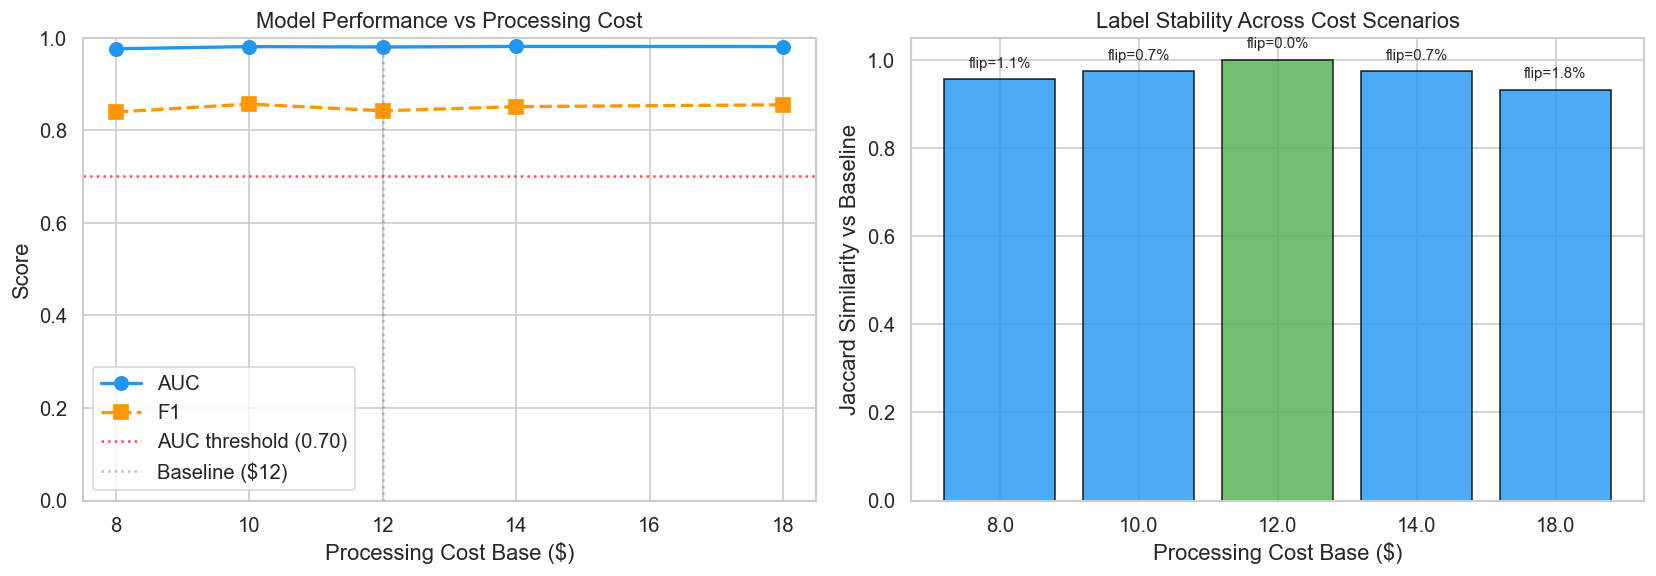

Saved: c:\Users\folij077\OneDrive - GUSCanada\SCHOOL\Winter 2026\Capstone\bQuery_theLook\unfc-capstone-project\reports\rq3\sensitivity_cost_analysis.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: AUC and F1 vs base cost
ax1 = axes[0]
ax1.plot(cost_summary["base_cost"], cost_summary["best_auc"],
         "o-", color="#2196F3", linewidth=2, markersize=8, label="AUC")
ax1.plot(cost_summary["base_cost"], cost_summary["f1"],
         "s--", color="#FF9800", linewidth=2, markersize=8, label="F1")
ax1.axhline(y=0.70, color="red", linestyle=":", alpha=0.7, label="AUC threshold (0.70)")
ax1.axvline(x=12.0, color="gray", linestyle=":", alpha=0.5, label="Baseline ($12)")
ax1.set_xlabel("Processing Cost Base ($)")
ax1.set_ylabel("Score")
ax1.set_title("Model Performance vs Processing Cost")
ax1.legend(loc="best")
ax1.set_ylim(0, 1)

# Panel B: Jaccard similarity vs baseline
ax2 = axes[1]
ax2.bar(
    cost_stability["scenario"].astype(str),
    cost_stability["jaccard_similarity"],
    color=["#4CAF50" if s == 12.0 else "#2196F3" for s in cost_stability["scenario"]],
    edgecolor="black",
    alpha=0.8,
)
ax2.set_xlabel("Processing Cost Base ($)")
ax2.set_ylabel("Jaccard Similarity vs Baseline")
ax2.set_title("Label Stability Across Cost Scenarios")
ax2.set_ylim(0, 1.05)

# Add flip rate as text on bars
for i, row in cost_stability.iterrows():
    ax2.text(
        i, row["jaccard_similarity"] + 0.02,
        f"flip={row['flip_rate']:.1%}",
        ha="center", va="bottom", fontsize=9,
    )

plt.tight_layout()
plt.savefig(rq3_reports / "sensitivity_cost_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {rq3_reports / 'sensitivity_cost_analysis.png'}")

## 5. Analysis B: Threshold Sensitivity (50th–90th Percentile)

Using the baseline $12 processing cost, vary the percentile threshold for the binary target variable.

In [8]:
threshold_summary = run_threshold_sensitivity(
    customer_targets_base_df=baseline_merged,
    thresholds=SENSITIVITY_THRESHOLDS,
)

print("\n=== Threshold Sensitivity Summary ===")
display(threshold_summary.round(4))

INFO: === Threshold sensitivity: percentile=0.50 ===
INFO: Imputed 0 missing values in 'customer_tenure_days' with median=1281.0000
INFO: Imputed 0 missing values in 'purchase_recency_days' with median=305.0000
INFO: Split: train=9590 (50.0% positive), test=2398 (50.0% positive)
INFO: Gate 2 (correlation): |r(order_frequency, customer_return_rate)|=0.852 > 0.85, dropping 'order_frequency'
INFO: Gate 2 (correlation): |r(total_sales, total_margin)|=0.993 > 0.85, dropping 'total_sales'
INFO: Gate 2 (correlation): |r(avg_item_price, avg_item_margin)|=0.987 > 0.85, dropping 'avg_item_margin'
INFO: Gate 3 (univariate): 'customer_tenure_days' p=4.8230e-01 > alpha=5.5556e-03, dropping
INFO: Gate 3 (univariate): 'purchase_recency_days' p=1.1447e-01 > alpha=5.5556e-03, dropping
INFO: Feature screening: 7/12 candidates survived all gates
INFO: Training Random Forest...
INFO: Random Forest -- CV AUC: 0.9685, Test AUC: 0.9664, F1: 0.8899
INFO: === Threshold sensitivity: percentile=0.60 ===
INFO: Im


=== Threshold Sensitivity Summary ===


,threshold,best_auc,f1,precision,recall,positive_rate,n_positive,n_total,n_surviving_features,surviving_features
0,0.50,0.9664,0.8899,0.9037,0.8766,0.5000,5994,11988,7,"return_frequency, customer_return_rate, avg_ba..."
1,0.60,0.9733,0.8811,0.8593,0.9041,0.4000,4795,11988,8,"order_frequency, return_frequency, customer_re..."
2,0.70,0.9773,0.8650,0.8223,0.9125,0.3001,3597,11988,7,"return_frequency, customer_return_rate, avg_ba..."
3,0.75,0.9798,0.8419,0.7822,0.9115,0.2500,2997,11988,7,"return_frequency, customer_return_rate, avg_ba..."
4,0.80,0.9848,0.8514,0.7886,0.9250,0.2000,2398,11988,7,"return_frequency, customer_return_rate, avg_ba..."
5,0.90,0.9879,0.7862,0.6706,0.9500,0.1000,1199,11988,8,"order_frequency, return_frequency, customer_re..."


## 6. Threshold Sensitivity Visualizations

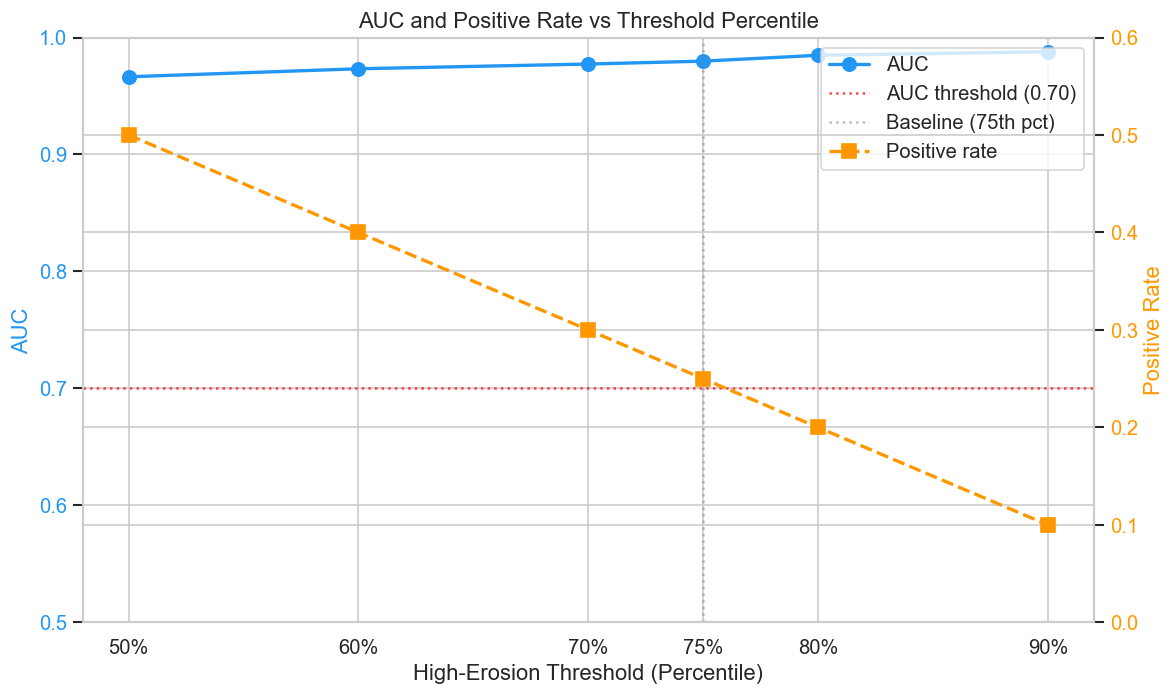

Saved: c:\Users\folij077\OneDrive - GUSCanada\SCHOOL\Winter 2026\Capstone\bQuery_theLook\unfc-capstone-project\reports\rq3\sensitivity_threshold_analysis.png


In [9]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary axis: AUC
color_auc = "#2196F3"
ax1.plot(
    threshold_summary["threshold"],
    threshold_summary["best_auc"],
    "o-", color=color_auc, linewidth=2, markersize=8, label="AUC",
)
ax1.axhline(y=0.70, color="red", linestyle=":", alpha=0.7, label="AUC threshold (0.70)")
ax1.axvline(x=0.75, color="gray", linestyle=":", alpha=0.5, label="Baseline (75th pct)")
ax1.set_xlabel("High-Erosion Threshold (Percentile)")
ax1.set_ylabel("AUC", color=color_auc)
ax1.tick_params(axis="y", labelcolor=color_auc)
ax1.set_ylim(0.5, 1.0)

# Secondary axis: Positive rate
ax2 = ax1.twinx()
color_rate = "#FF9800"
ax2.plot(
    threshold_summary["threshold"],
    threshold_summary["positive_rate"],
    "s--", color=color_rate, linewidth=2, markersize=8, label="Positive rate",
)
ax2.set_ylabel("Positive Rate", color=color_rate)
ax2.tick_params(axis="y", labelcolor=color_rate)
ax2.set_ylim(0, 0.6)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.set_title("AUC and Positive Rate vs Threshold Percentile")
ax1.set_xticks(threshold_summary["threshold"])
ax1.set_xticklabels([f"{t:.0%}" for t in threshold_summary["threshold"]])

plt.tight_layout()
plt.savefig(rq3_reports / "sensitivity_threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {rq3_reports / 'sensitivity_threshold_analysis.png'}")

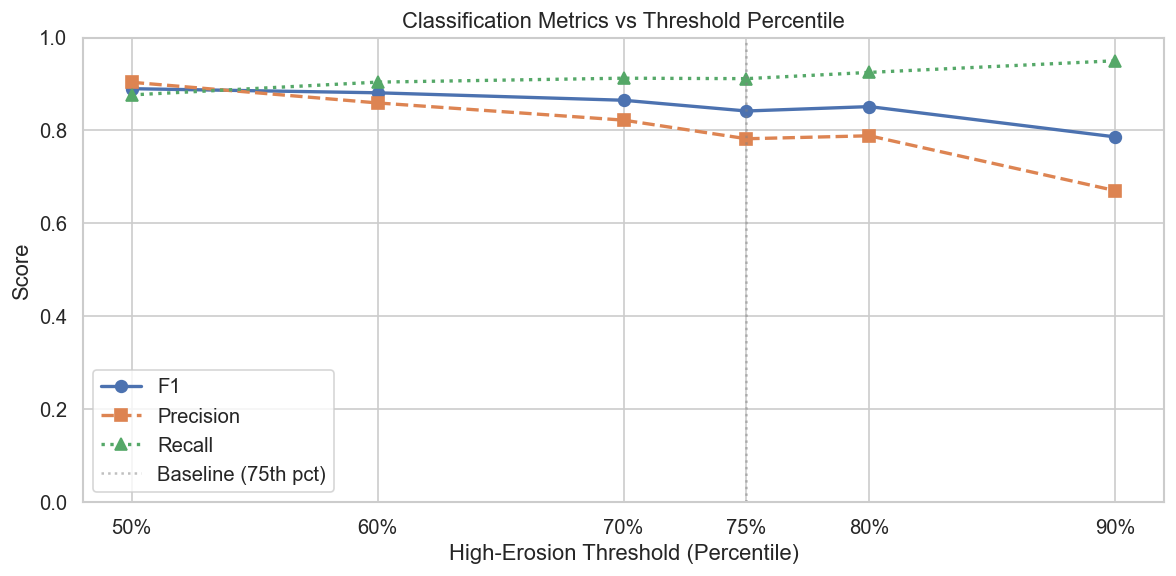

Saved: c:\Users\folij077\OneDrive - GUSCanada\SCHOOL\Winter 2026\Capstone\bQuery_theLook\unfc-capstone-project\reports\rq3\sensitivity_threshold_metrics.png


In [10]:
# Additional: F1, Precision, Recall across thresholds
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(threshold_summary["threshold"], threshold_summary["f1"],
        "o-", linewidth=2, markersize=7, label="F1")
ax.plot(threshold_summary["threshold"], threshold_summary["precision"],
        "s--", linewidth=2, markersize=7, label="Precision")
ax.plot(threshold_summary["threshold"], threshold_summary["recall"],
        "^:", linewidth=2, markersize=7, label="Recall")
ax.axvline(x=0.75, color="gray", linestyle=":", alpha=0.5, label="Baseline (75th pct)")

ax.set_xlabel("High-Erosion Threshold (Percentile)")
ax.set_ylabel("Score")
ax.set_title("Classification Metrics vs Threshold Percentile")
ax.set_xticks(threshold_summary["threshold"])
ax.set_xticklabels([f"{t:.0%}" for t in threshold_summary["threshold"]])
ax.legend(loc="best")
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(rq3_reports / "sensitivity_threshold_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {rq3_reports / 'sensitivity_threshold_metrics.png'}")

## 7. Summary

Consolidated findings for technical documentation.

In [11]:
print("=" * 70)
print("RQ3 SENSITIVITY ANALYSIS SUMMARY")
print("=" * 70)

# Cost sensitivity
print("\n--- Analysis A: Processing Cost Sensitivity ---")
print(f"Costs tested: {list(cost_summary['base_cost'])}")
print(f"AUC range: [{cost_summary['best_auc'].min():.4f}, {cost_summary['best_auc'].max():.4f}]")
print(f"All above 0.70 threshold: {(cost_summary['best_auc'] > 0.70).all()}")
print(f"F1 range: [{cost_summary['f1'].min():.4f}, {cost_summary['f1'].max():.4f}]")
print(f"Label stability (Jaccard vs $12):")
for _, row in cost_stability.iterrows():
    print(f"  ${row['scenario']:.0f}: Jaccard={row['jaccard_similarity']:.4f}, flip_rate={row['flip_rate']:.4f}")

# Threshold sensitivity
print("\n--- Analysis B: Threshold Sensitivity ---")
print(f"Thresholds tested: {list(threshold_summary['threshold'])}")
print(f"AUC range: [{threshold_summary['best_auc'].min():.4f}, {threshold_summary['best_auc'].max():.4f}]")
print(f"All above 0.70 threshold: {(threshold_summary['best_auc'] > 0.70).all()}")
print(f"Positive rate range: [{threshold_summary['positive_rate'].min():.2%}, {threshold_summary['positive_rate'].max():.2%}]")

# Overall conclusion
all_auc_above = (
    (cost_summary['best_auc'] > 0.70).all()
    and (threshold_summary['best_auc'] > 0.70).all()
)
print("\n--- Overall Conclusion ---")
if all_auc_above:
    print("ROBUST: AUC exceeds 0.70 across ALL 11 sensitivity scenarios.")
    print("The RQ3 finding (H0 rejected) is robust to alternative parameter values.")
else:
    n_below_cost = (cost_summary['best_auc'] <= 0.70).sum()
    n_below_thresh = (threshold_summary['best_auc'] <= 0.70).sum()
    print(f"PARTIAL: {n_below_cost} cost and {n_below_thresh} threshold scenarios fall below AUC 0.70.")
    print("The RQ3 finding may be sensitive to specific parameter choices.")

RQ3 SENSITIVITY ANALYSIS SUMMARY

--- Analysis A: Processing Cost Sensitivity ---
Costs tested: [8.0, 10.0, 12.0, 14.0, 18.0]
AUC range: [0.9759, 0.9810]
All above 0.70 threshold: True
F1 range: [0.8393, 0.8565]
Label stability (Jaccard vs $12):
  $8: Jaccard=0.9563, flip_rate=0.0112
  $10: Jaccard=0.9743, flip_rate=0.0065
  $12: Jaccard=1.0000, flip_rate=0.0000
  $14: Jaccard=0.9743, flip_rate=0.0065
  $18: Jaccard=0.9323, flip_rate=0.0175

--- Analysis B: Threshold Sensitivity ---
Thresholds tested: [0.5, 0.6, 0.7, 0.75, 0.8, 0.9]
AUC range: [0.9664, 0.9879]
All above 0.70 threshold: True
Positive rate range: [10.00%, 50.00%]

--- Overall Conclusion ---
ROBUST: AUC exceeds 0.70 across ALL 11 sensitivity scenarios.
The RQ3 finding (H0 rejected) is robust to alternative parameter values.


## 8. Export Results

In [12]:
# Save summary DataFrames
cost_summary.to_csv(rq3_reports / "sensitivity_cost_summary.csv", index=False)
cost_stability.to_csv(rq3_reports / "sensitivity_cost_stability.csv", index=False)
threshold_summary.to_csv(rq3_reports / "sensitivity_threshold_summary.csv", index=False)

print("Exported artifacts to reports/rq3/:")
print("  - sensitivity_cost_summary.csv")
print("  - sensitivity_cost_stability.csv")
print("  - sensitivity_threshold_summary.csv")
print("  - sensitivity_cost_analysis.png")
print("  - sensitivity_threshold_analysis.png")
print("  - sensitivity_threshold_metrics.png")

Exported artifacts to reports/rq3/:
  - sensitivity_cost_summary.csv
  - sensitivity_cost_stability.csv
  - sensitivity_threshold_summary.csv
  - sensitivity_cost_analysis.png
  - sensitivity_threshold_analysis.png
  - sensitivity_threshold_metrics.png
